# 09 — MLflow Experiment Tracking: Variable Addition Study

Systematically compare how adding feature groups improves quantile regression
performance for the car valuation tool.

| Spec | Description |
|---|---|
| `lean_ohe` | Lean features + Brand/Model one-hot encoding |
| `lean_median_encoded` | Lean features, target-encoded aggregates (no OHE) |
| `lean_full` | Full lean features incl. distribution quantile stats |
| `extended_km` | Lean full + km/mileage features |
| `extended_km_energie_hp` | Extended km + horsepower polynomials + energie OHE |

Each spec is trained at **q15 / q50 / q85** and tracked in MLflow.

## 1. Setup and Imports

In [1]:
import os, sys, json, subprocess
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import polars as pl
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.lightgbm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

import data_processing
from config import DATA_PATH
from features.feature_engineering import CarPriceFeatureEngineer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Project root: {project_root}")
print(f"MLflow version: {mlflow.__version__}")
print("✓ All imports successful")

Project root: /Users/brunobrumbrum/car_price_prediction
MLflow version: 3.10.1
✓ All imports successful


## 2. MLflow Experiment Configuration

In [ ]:
df_other_ci = pl.read_csv(project_root / 'data' / 'customs_ci_filtered.csv')
df_other_ci

NUMDEC,ANNEE,CHASSIS,PREMIERE_MIS_CIRCULAT,MARQUE,MODELE,PUISSANCE,KILOMETRAGE,PAYS_ORIGINE,VALEURFOB,VALCAF,brand,model,year,VALCAF_EUR
str,i64,str,str,str,str,i64,i64,str,i64,i64,str,str,i64,f64
"""2024CIAB6C58""",2024,"""SALKP9FUXPA020031""","""2023-01-01 00:00:00.0000000""","""LAND ROVER""","""RANGE ROVER""",17,2274,"""Etats-Unis""",71565000,72737560,"""landrover""","""range rover""",2023,109106.34
"""2024CIAB6C95""",2024,"""5TFAX5GN3LX178687""","""2020-01-01 00:00:00.0000000""","""TOYOTA""","""TACOMA""",15,960000,"""Japon""",9201522,9801522,"""toyota""","""hilux""",2020,14702.283
"""2024CIAB6C28""",2024,"""JE4NR62R5LJ715354""","""2020-01-01 00:00:00.0000000""","""MITSUBISHI""","""PAJERO""",22,50000,"""Japon""",10000877,10400877,"""mitsubishi""","""pajero""",2020,15601.3155
"""2024CIAB6C65""",2024,"""2HKRW2H86KH125070""","""2019-01-01 00:00:00.0000000""","""HONDA""","""CR-V""",9,70000,"""Japon""",5652550,6052550,"""honda""","""crv""",2019,9078.825
"""2024CIAB6C131""",2024,"""5TDJGRFH9HS035761""","""2018-01-01 00:00:00.0000000""","""TOYOTA""","""HIGHLANDER""",21,180000,"""Japon""",7986957,8386957,"""toyota""","""highlander""",2018,12580.4355
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024CIAB6C69""",2024,"""KNDPM3AC2K7582173""","""2019-01-01 00:00:00.0000000""","""KIA""","""SPORTAGE""",14,100000,"""Coree, Republique de (Coree du…",5275234,5675234,"""kia""","""sportage""",2019,8512.851
"""2024CIAB6C107""",2024,"""2T3RWRFV9LW097695""","""2020-01-01 00:00:00.0000000""","""TOYOTA""","""RAV4""",14,45000,"""Japon""",7256294,7656294,"""toyota""","""rav4""",2020,11484.441
"""2024CIAB6C125""",2024,"""5TDXBRCH4MS015053""","""2021-01-01 00:00:00.0000000""","""TOYOTA""","""HIGHLANDER""",14,67000,"""Canada""",8467446,8867446,"""toyota""","""highlander""",2021,13301.169


In [2]:
MLFLOW_DIR = project_root / "mlruns"
MLFLOW_DIR.mkdir(exist_ok=True)
EXPERIMENT_NAME = "car_valuation_variable_addition_study"
DATASET_SNAPSHOT_ID = "le_boncoin_13_oct_2025"
TRAIN_TEST_SEED = 42

mlflow.set_tracking_uri(f"file://{MLFLOW_DIR}")
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    experiment_id = mlflow.create_experiment(
        EXPERIMENT_NAME,
        tags={"dataset": DATASET_SNAPSHOT_ID, "objective": "quantile_regression"},
    )
else:
    experiment_id = experiment.experiment_id

try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"],
        cwd=project_root, stderr=subprocess.DEVNULL,
    ).decode().strip()
except Exception:
    GIT_COMMIT = "unknown"

print(f"Experiment : {EXPERIMENT_NAME}  (id={experiment_id})")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Git commit : {GIT_COMMIT}")

Experiment : car_valuation_variable_addition_study  (id=552431252291930750)
Tracking URI: file:///Users/brunobrumbrum/car_price_prediction/mlruns
Git commit : e959b1a


## 3. Data Loading and Train/Test Split

In [3]:
data_dir = Path(os.path.join(DATA_PATH, "le_boncoin_13_oct_2025"))
print(f"Loading from: {data_dir}")

df_raw = data_processing.load_car_data(data_dir)
df = data_processing.clean_car_data(df_raw)
df = df.with_columns(pl.col("price").log().alias("log_price"))

print(f"Dataset shape: {df.shape}")

# Extract brand/model BEFORE FE (FE drops them)
train_indices, test_indices = train_test_split(
    range(len(df)), test_size=0.2, random_state=TRAIN_TEST_SEED
)
df_train = df[train_indices]
df_test  = df[test_indices]

brands_test = df_test["brand"].to_numpy()
models_test = df_test["model"].to_numpy()
y_test_eur  = df_test["price"].to_numpy()
y_test_log  = df_test["log_price"].to_numpy()

print(f"Train: {len(df_train):,}  |  Test: {len(df_test):,}")
print("✓ Data loaded and split")

Loading from: /Users/brunobrumbrum/Documents/data/car_price_prediction/le_boncoin_13_oct_2025
📊 Parsing horsepower from puissance_din column...
✅ Loaded 732,427 rows with horsepower parsed
   Note: 'energie' column contains fuel type (kept as-is)
(732427, 36)
🧹 Starting data cleaning pipeline...

1️⃣ Converting data types and normalizing text...
   Original: 732,427 rows
   After conversion: 732,426 rows
   Removed (invalid price): 1
   Unique brands: 145, Unique models: 1646

2️⃣ Removing antique cars (pre-1990)...
   Removed 14,536 antique cars

3️⃣ Removing 'autre' entries...
   Removed 4,347 'autre' entries

4️⃣ Cleaning horsepower...
   HP cleaning: dropped 5620 cars <50HP, 114 cars >1000HP, 35437 outliers (IQR per brand), 0 missing HP
   Remaining dataset - Mean HP: 139.7, Median HP: 125.0

5️⃣ Dropping rare brands (<400 cars)...
   Dropped 3,805 cars from 65 rare brands (< 400 observations)
   Remaining: 43 brands

6️⃣ Removing price/km outliers (IQR 1.5× for price, 1.5× for km)

## 4. Feature Generation (DRY — fit once per FE variant)

In [4]:
# FE variant 1: full features (no OHE)
fe_full = CarPriceFeatureEngineer(
    current_year=2025,
    brand_onehot=False,
    model_onehot=False,
    add_horsepower_features=True,
    add_energie_ohe=True,
)
fe_full.fit(df_train.drop(["price", "log_price"]), df_train["price"])
df_train_fe = fe_full.transform(df_train)
df_test_fe  = fe_full.transform(df_test)
print(f"FE_full → train {df_train_fe.shape}, test {df_test_fe.shape}")

# FE variant 2: OHE (lean_ohe spec)
fe_ohe = CarPriceFeatureEngineer(
    current_year=2025,
    brand_onehot=True,
    model_onehot=True,
    add_horsepower_features=False,
    add_energie_ohe=False,
)
fe_ohe.fit(df_train.drop(["price", "log_price"]), df_train["price"])
df_train_ohe = fe_ohe.transform(df_train)
df_test_ohe  = fe_ohe.transform(df_test)
print(f"FE_ohe  → train {df_train_ohe.shape}, test {df_test_ohe.shape}")
print("✓ Feature engineering complete")

FE_full → train (496734, 69), test (124184, 69)
FE_ohe  → train (496734, 1066), test (124184, 1066)
✓ Feature engineering complete


## 5. Model Specification Registry

In [20]:
len(KM_FEATURES)

18

In [21]:
OHE_BRAND_COLS

['brand_alfa romeo',
 'brand_alpine',
 'brand_audi',
 'brand_bmw',
 'brand_chevrolet',
 'brand_chrysler',
 'brand_citroen',
 'brand_cupra',
 'brand_dacia',
 'brand_dodge',
 'brand_ds',
 'brand_ferrari',
 'brand_fiat',
 'brand_ford',
 'brand_honda',
 'brand_hyundai',
 'brand_jaguar',
 'brand_jeep',
 'brand_kia',
 'brand_lancia',
 'brand_landrover',
 'brand_lexus',
 'brand_maserati',
 'brand_mazda',
 'brand_mercedesbenz',
 'brand_mgmg motor',
 'brand_mini',
 'brand_mitsubishi',
 'brand_nissan',
 'brand_opel',
 'brand_peugeot',
 'brand_porsche',
 'brand_renault',
 'brand_seat',
 'brand_skoda',
 'brand_smart',
 'brand_subaru',
 'brand_suzuki',
 'brand_tesla',
 'brand_toyota',
 'brand_volkswagen',
 'brand_volvo',
 'brand_top25_price',
 'brand_bottom25_price',
 'brand_top5_price',
 'brand_p25_log_price',
 'brand_p75_log_price',
 'brand_p90_log_price',
 'brand_iqr_log_price']

In [5]:
LEAN_BASE_FEATURES = [
    "car_age", "is_almost_new", "decade", "sqrt_age", "age_squared", "age_cubed",
    "brand_avg_age", "brand_median_age",
    "brand_mean_log_price", "brand_median_log_price", "brand_std_log_price",
    "model_count", "model_popularity_ratio",
    "model_mean_log_price", "model_median_log_price", "model_std_log_price",
    "brand_top25_price", "brand_bottom25_price", "brand_top5_price",
    "model_top25_price", "model_bottom25_price", "model_top5_price",
    "model_rank_within_brand",
    "brand_p25_log_price", "brand_p75_log_price", "brand_p90_log_price", "brand_iqr_log_price",
    "model_p25_log_price", "model_p75_log_price", "model_p90_log_price", "model_iqr_log_price",
]
KM_FEATURES = [
    "km", "km_per_year", "log_km", "log_km_per_year", "sqrt_km",
    "mileage", "mileage_squared", "mileage_cubed",
    "is_low_mileage", "is_high_mileage", "is_nearly_new_mileage",
    "age_km_interaction", "age_mileage", "age_squared_mileage",
    "age_mileage_squared", "is_low_use_recent", "is_high_use_new", "is_garage_queen",
]
HP_FEATURES = ["hp", "hp_squared", "hp_cubed", "sqrt_hp"]
ENERGIE_COLS = [c for c in df_test_fe.columns if c.startswith("energie_")]
OHE_BRAND_COLS = [c for c in df_test_ohe.columns if c.startswith("brand_")]
OHE_MODEL_COLS = [c for c in df_test_ohe.columns if c.startswith("model_")]

print(f"Lean base features: {len(LEAN_BASE_FEATURES)}")
print(f"KM features       : {len(KM_FEATURES)}")
print(f"HP features       : {len(HP_FEATURES)}")
print(f"Energie OHE cols  : {ENERGIE_COLS}")
print(f"OHE brand cols    : {len(OHE_BRAND_COLS)}")

Lean base features: 31
KM features       : 18
HP features       : 4
Energie OHE cols  : ['energie_Diesel', 'energie_Essence', 'energie_GPL', 'energie_Gaz Naturel (GNV)', 'energie_Hybride', 'energie_Hybride Rechargeable', 'energie_Hydrogène', 'energie_Électrique']
OHE brand cols    : 49


In [6]:
def _avail(feat_list, df_pd):
    present = [f for f in feat_list if f in df_pd.columns]
    missing = [f for f in feat_list if f not in df_pd.columns]
    if missing:
        print(f"  ⚠ skipped (not in df): {missing}")
    return present

ALWAYS_DROP = {"log_price", "year", "age_category", "mileage_category", "price"}

MODEL_SPECS = {
    "lean_ohe": {
        "description": "Lean + Brand/Model OHE",
        "use_ohe": True,
        "extra_features": [],
    },
    "lean_median_encoded": {
        "description": "Lean target-encoded aggregates (no OHE)",
        "use_ohe": False,
        "extra_features": [],
    },
    "lean_full": {
        "description": "Full lean features incl. distribution quantile stats",
        "use_ohe": False,
        "extra_features": [],
    },
    "extended_km": {
        "description": "Lean full + km/mileage features",
        "use_ohe": False,
        "extra_features": KM_FEATURES,
    },
    "extended_km_energie_hp": {
        "description": "Extended km + HP polynomials + energie OHE",
        "use_ohe": False,
        "extra_features": KM_FEATURES + HP_FEATURES + ENERGIE_COLS,
    },
}
print("Model specs:", list(MODEL_SPECS.keys()))

Model specs: ['lean_ohe', 'lean_median_encoded', 'lean_full', 'extended_km', 'extended_km_energie_hp']


## 6. Helper Functions

In [7]:
def prepare_xy(df_polars, feature_cols, target_col="log_price"):
    cols = [c for c in feature_cols if c in df_polars.columns]
    df_pd = df_polars.select(cols + [target_col]).to_pandas()
    y = df_pd[target_col].to_numpy()
    X = df_pd.drop(columns=[target_col])
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
    X = X.fillna(0)
    return X, y


def train_quantile_model(X_train, y_train, alpha: float) -> lgb.LGBMRegressor:
    model = lgb.LGBMRegressor(
        objective="quantile", alpha=alpha,
        learning_rate=0.1, n_estimators=5000,
        random_state=42, verbose=-1,
    )
    model.fit(X_train, y_train)
    return model


def compute_q50_metrics(y_true_eur, y_pred_log):
    y_pred_eur = np.exp(y_pred_log)
    mae  = mean_absolute_error(y_true_eur, y_pred_eur)
    rmse = np.sqrt(mean_squared_error(y_true_eur, y_pred_eur))
    r2   = r2_score(y_true_eur, y_pred_eur)
    mape = np.mean(np.abs((y_true_eur - y_pred_eur) / np.clip(y_true_eur, 1, None))) * 100
    return {"mae_eur": mae, "mape_pct": mape, "rmse_eur": rmse, "r2": r2}


def compute_quantile_calibration(y_true_eur, y15, y50, y85):
    calib_q15 = float(np.mean(y_true_eur <= y15))
    calib_q50 = float(np.mean(y_true_eur <= y50))
    calib_q85 = float(np.mean(y_true_eur <= y85))
    coverage  = float(np.mean((y_true_eur >= y15) & (y_true_eur <= y85)))
    return {
        "coverage_70pct": coverage,
        "calib_q15": calib_q15, "calib_q50": calib_q50, "calib_q85": calib_q85,
        "calib_err_q15": abs(calib_q15 - 0.15),
        "calib_err_q50": abs(calib_q50 - 0.50),
        "calib_err_q85": abs(calib_q85 - 0.85),
    }


def compute_interval_metrics(y15, y85, y_true_eur):
    width = y85 - y15
    rel_w = width / np.clip(y_true_eur, 1, None) * 100
    return {
        "mean_interval_width_eur":    float(np.mean(width)),
        "median_interval_width_eur":  float(np.median(width)),
        "mean_relative_width_pct":    float(np.mean(rel_w)),
    }


def compute_per_brand_mae(y_true_eur, y_pred_eur, brands):
    df = pd.DataFrame({"actual": y_true_eur, "pred": y_pred_eur, "brand": brands})
    return df.groupby("brand").apply(lambda g: mean_absolute_error(g["actual"], g["pred"])).rename("mae_eur").sort_values()


def compute_per_model_mae(y_true_eur, y_pred_eur, models):
    df = pd.DataFrame({"actual": y_true_eur, "pred": y_pred_eur, "model": models})
    return df.groupby("model").apply(lambda g: mean_absolute_error(g["actual"], g["pred"])).rename("mae_eur").sort_values()

print("✓ Helper functions defined")

✓ Helper functions defined


In [8]:
ARTIFACTS_DIR = project_root / "output" / "mlflow_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def log_quantile_run(spec_name, q_label, alpha, model, feature_cols, metrics, fe_config, parent_run_id):
    run_name = f"{spec_name}_{q_label}"
    with mlflow.start_run(
        run_name=run_name, experiment_id=experiment_id, nested=True,
        parent_run_id=parent_run_id,
        tags={"spec": spec_name, "quantile": q_label, "git_commit": GIT_COMMIT},
    ):
        mlflow.log_params({
            "spec": spec_name, "quantile": q_label, "alpha": alpha,
            "n_features": len(feature_cols), "dataset": DATASET_SNAPSHOT_ID,
            **{f"fe_{k}": str(v) for k, v in fe_config.items()},
        })
        mlflow.log_metrics(metrics)

        model_path = ARTIFACTS_DIR / f"{run_name}_model.pkl"
        feat_path  = ARTIFACTS_DIR / f"{run_name}_features.json"
        fe_path    = ARTIFACTS_DIR / f"{run_name}_fe_config.json"

        joblib.dump(model, model_path)
        feat_path.write_text(json.dumps(feature_cols))
        fe_path.write_text(json.dumps(fe_config))

        mlflow.log_artifact(str(model_path))
        mlflow.log_artifact(str(feat_path))
        mlflow.log_artifact(str(fe_path))

print(f"Artifacts dir: {ARTIFACTS_DIR}")

Artifacts dir: /Users/brunobrumbrum/car_price_prediction/output/mlflow_artifacts


## 7. Main Training Loop

Trains 5 specs × 3 quantiles = **15 child runs** inside 5 parent MLflow runs.

In [9]:
QUANTILES = [("q15", 0.15), ("q50", 0.50), ("q85", 0.85)]
results_store = {}

for spec_name, spec in MODEL_SPECS.items():
    print(f"\n{'='*60}")
    print(f"  SPEC: {spec_name}  |  {spec['description']}")
    print(f"{'='*60}")

    if spec["use_ohe"]:
        df_tr, df_te = df_train_ohe, df_test_ohe
        feat_cols = [c for c in df_tr.columns if c not in ALWAYS_DROP and c not in ("brand", "model")]
        fe_config = {"brand_onehot": True, "model_onehot": True, "add_horsepower_features": False, "add_energie_ohe": False}
    else:
        df_tr, df_te = df_train_fe, df_test_fe
        feat_cols = _avail(LEAN_BASE_FEATURES + spec["extra_features"], df_tr.to_pandas())
        fe_config = {
            "brand_onehot": False, "model_onehot": False,
            "add_horsepower_features": any(f in spec["extra_features"] for f in HP_FEATURES),
            "add_energie_ohe": any(f in spec["extra_features"] for f in ENERGIE_COLS),
        }

    X_tr, y_tr_log = prepare_xy(df_tr, feat_cols)
    X_te, y_te_log = prepare_xy(df_te, feat_cols)
    print(f"  Features: {X_tr.shape[1]}   Train: {len(X_tr):,}")

    results_store[spec_name] = {}
    trained_models = {}

    with mlflow.start_run(
        run_name=spec_name, experiment_id=experiment_id,
        tags={"spec": spec_name, "type": "parent_run", "git_commit": GIT_COMMIT},
    ) as parent_run:
        mlflow.log_params({
            "spec": spec_name, "n_features": X_tr.shape[1],
            "n_train": len(X_tr), "n_test": len(X_te),
        })

        for q_label, alpha in QUANTILES:
            print(f"    Training {q_label}...", end=" ", flush=True)
            model = train_quantile_model(X_tr, y_tr_log, alpha)
            y_pred_log = model.predict(X_te)
            trained_models[q_label] = (model, y_pred_log, np.exp(y_pred_log))
            print("done")

        y15 = trained_models["q15"][2]
        y50 = trained_models["q50"][2]
        y85 = trained_models["q85"][2]
        interval_m = compute_interval_metrics(y15, y85, y_test_eur)
        calib_m    = compute_quantile_calibration(y_test_eur, y15, y50, y85)

        for q_label, alpha in QUANTILES:
            model, y_pred_log, y_pred_eur = trained_models[q_label]
            q50_m = compute_q50_metrics(y_test_eur, y_pred_log) if q_label == "q50" else {}
            all_metrics = {
                **{f"q50_{k}": v for k, v in q50_m.items()},
                **{f"interval_{k}": v for k, v in interval_m.items()},
                **{f"calib_{k}": v for k, v in calib_m.items()},
            }
            log_quantile_run(spec_name, q_label, alpha, model, list(X_tr.columns), all_metrics, fe_config, parent_run.info.run_id)
            results_store[spec_name][q_label] = {
                "model": model, "y_pred_log": y_pred_log, "y_pred_eur": y_pred_eur,
                "metrics": all_metrics, "feature_cols": list(X_tr.columns),
            }

        q50_mae = results_store[spec_name]["q50"]["metrics"].get("q50_mae_eur", 0)
        mlflow.log_metrics({"q50_mae_eur": q50_mae, **{f"interval_{k}": v for k, v in interval_m.items()}})
        print(f"  ✓ Done — MAE(q50): €{q50_mae:,.0f}")

print("\n✅ All specs trained and logged to MLflow")


  SPEC: lean_ohe  |  Lean + Brand/Model OHE
  Features: 1061   Train: 496,734
    Training q15... done
    Training q50... done
    Training q85... done
  ✓ Done — MAE(q50): €1,721

  SPEC: lean_median_encoded  |  Lean target-encoded aggregates (no OHE)
  Features: 31   Train: 496,734
    Training q15... done
    Training q50... done
    Training q85... done
  ✓ Done — MAE(q50): €2,561

  SPEC: lean_full  |  Full lean features incl. distribution quantile stats
  Features: 31   Train: 496,734
    Training q15... done
    Training q50... done
    Training q85... done
  ✓ Done — MAE(q50): €2,561

  SPEC: extended_km  |  Lean full + km/mileage features
  Features: 49   Train: 496,734
    Training q15... done
    Training q50... done
    Training q85... done
  ✓ Done — MAE(q50): €2,153

  SPEC: extended_km_energie_hp  |  Extended km + HP polynomials + energie OHE
  Features: 61   Train: 496,734
    Training q15... done
    Training q50... done
    Training q85... done
  ✓ Done — MAE(q50): 

## 8. Comparison Summary Table

In [10]:
rows = []
for spec_name, spec_res in results_store.items():
    m = spec_res["q50"]["metrics"]
    rows.append({
        "spec": spec_name,
        "n_features": len(spec_res["q50"]["feature_cols"]),
        "MAE_q50_eur":            m.get("q50_mae_eur", np.nan),
        "MAPE_q50_pct":           m.get("q50_mape_pct", np.nan),
        "RMSE_q50_eur":           m.get("q50_rmse_eur", np.nan),
        "R2_q50":                 m.get("q50_r2", np.nan),
        "coverage_70pct":         m.get("calib_coverage_70pct", np.nan),
        "mean_interval_width_eur":m.get("interval_mean_interval_width_eur", np.nan),
        "calib_err_q15":          m.get("calib_calib_err_q15", np.nan),
        "calib_err_q50":          m.get("calib_calib_err_q50", np.nan),
        "calib_err_q85":          m.get("calib_calib_err_q85", np.nan),
    })

summary_df = pd.DataFrame(rows).sort_values("MAE_q50_eur").reset_index(drop=True)
summary_df.index += 1
display(
    summary_df.style
    .format({
        "MAE_q50_eur": "€{:,.0f}", "MAPE_q50_pct": "{:.2f}%",
        "RMSE_q50_eur": "€{:,.0f}", "R2_q50": "{:.4f}",
        "coverage_70pct": "{:.3f}", "mean_interval_width_eur": "€{:,.0f}",
        "calib_err_q15": "{:.3f}", "calib_err_q50": "{:.3f}", "calib_err_q85": "{:.3f}",
    })
    .background_gradient(subset=["MAE_q50_eur"], cmap="RdYlGn_r")
    .background_gradient(subset=["R2_q50"], cmap="RdYlGn")
)

,spec,n_features,MAE_q50_eur,MAPE_q50_pct,RMSE_q50_eur,R2_q50,coverage_70pct,mean_interval_width_eur,calib_err_q15,calib_err_q50,calib_err_q85
1,extended_km_energie_hp,61,"€1,659",13.04%,"€3,255",0.9647,0.679,"€3,937",0.009,0.003,0.012
2,lean_ohe,1061,"€1,721",13.48%,"€3,320",0.9632,0.677,"€4,123",0.011,0.002,0.012
3,extended_km,49,"€2,153",15.79%,"€4,200",0.9412,0.679,"€5,187",0.009,0.002,0.011
4,lean_median_encoded,31,"€2,561",19.52%,"€4,753",0.9247,0.698,"€6,425",0.000,0.001,0.002
5,lean_full,31,"€2,561",19.52%,"€4,753",0.9247,0.698,"€6,425",0.000,0.001,0.002


## 9. Plots

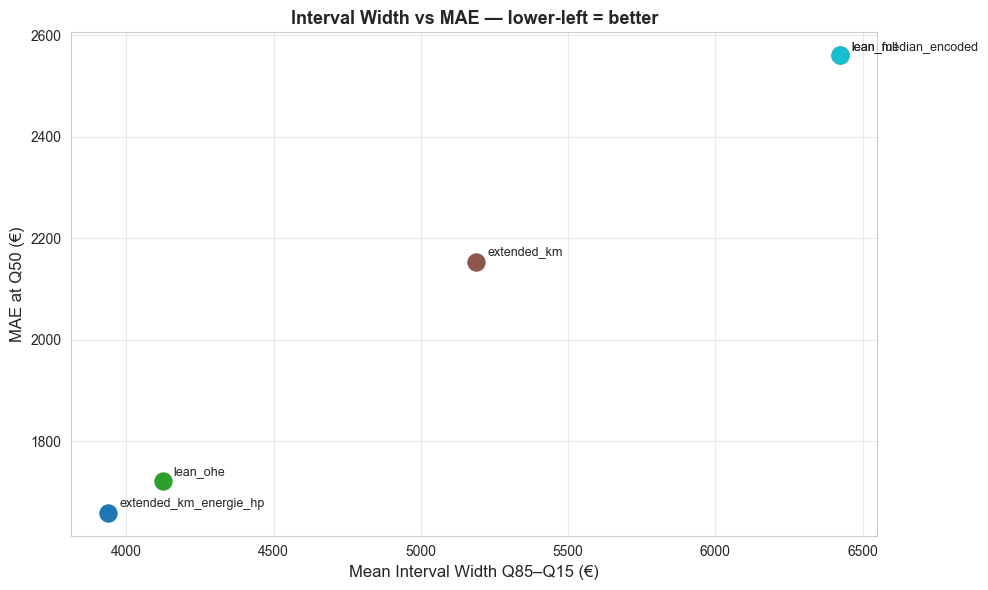

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.tab10(np.linspace(0, 1, len(summary_df)))
for i, row in summary_df.iterrows():
    ax.scatter(row["mean_interval_width_eur"], row["MAE_q50_eur"],
               color=cmap[i - 1], s=150, zorder=5)
    ax.annotate(row["spec"], (row["mean_interval_width_eur"], row["MAE_q50_eur"]),
                xytext=(8, 4), textcoords="offset points", fontsize=9)
ax.set_xlabel("Mean Interval Width Q85–Q15 (€)", fontsize=12)
ax.set_ylabel("MAE at Q50 (€)", fontsize=12)
ax.set_title("Interval Width vs MAE — lower-left = better", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "interval_width_vs_mae.png", dpi=120, bbox_inches="tight")
plt.show()

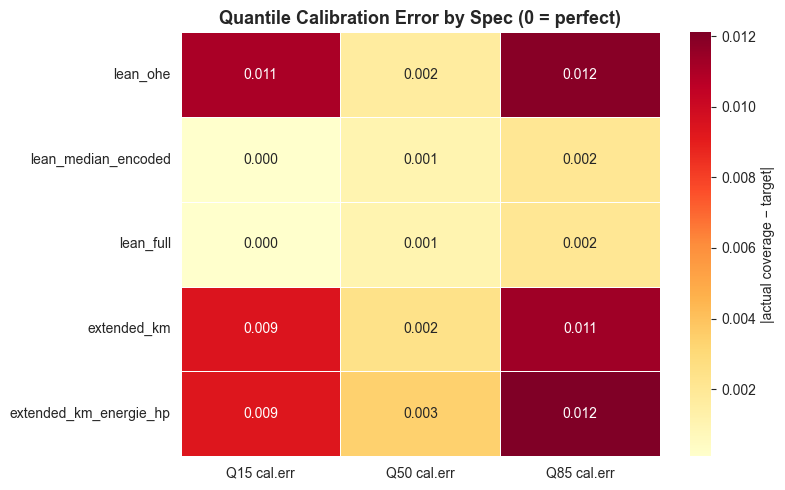

In [12]:
specs = list(results_store.keys())
calib_data = []
for s in specs:
    m = results_store[s]["q50"]["metrics"]
    calib_data.append({
        "Q15 cal.err": m.get("calib_calib_err_q15", np.nan),
        "Q50 cal.err": m.get("calib_calib_err_q50", np.nan),
        "Q85 cal.err": m.get("calib_calib_err_q85", np.nan),
    })
calib_df = pd.DataFrame(calib_data, index=specs)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(calib_df, annot=True, fmt=".3f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "|actual coverage − target|"})
ax.set_title("Quantile Calibration Error by Spec (0 = perfect)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "calibration_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

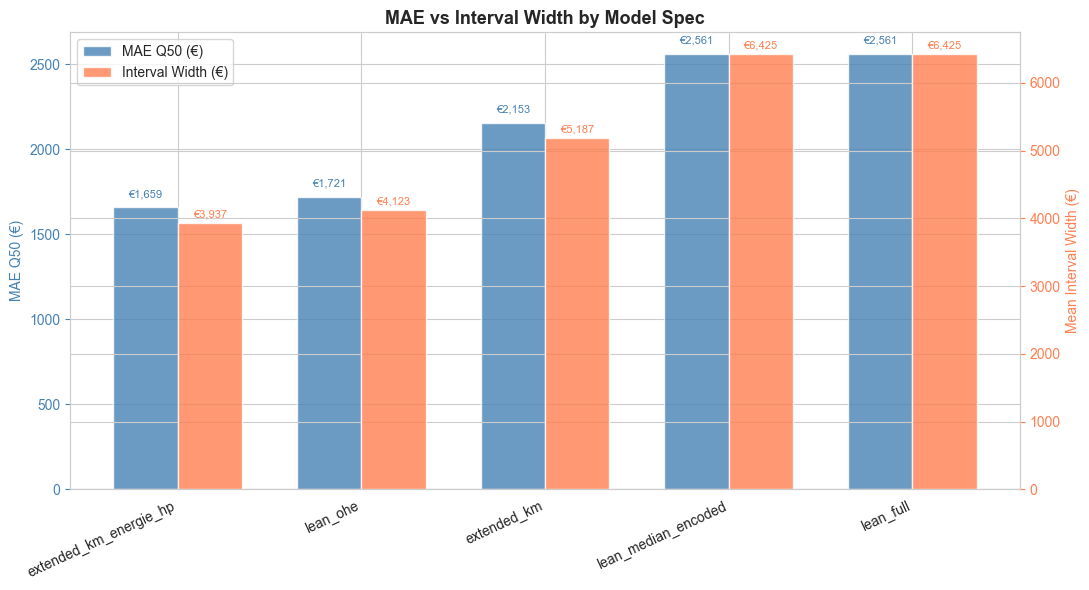

In [13]:
fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()
x = np.arange(len(summary_df))
w = 0.35
b1 = ax1.bar(x - w/2, summary_df["MAE_q50_eur"], w, label="MAE Q50 (€)", color="steelblue", alpha=0.8)
b2 = ax2.bar(x + w/2, summary_df["mean_interval_width_eur"], w, label="Interval Width (€)", color="coral", alpha=0.8)
ax1.set_xticks(x); ax1.set_xticklabels(summary_df["spec"], rotation=25, ha="right")
ax1.set_ylabel("MAE Q50 (€)", color="steelblue"); ax2.set_ylabel("Mean Interval Width (€)", color="coral")
ax1.tick_params(axis="y", colors="steelblue"); ax2.tick_params(axis="y", colors="coral")
for b in b1:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+50, f"€{b.get_height():,.0f}",
             ha="center", va="bottom", fontsize=8, color="steelblue")
for b in b2:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+50, f"€{b.get_height():,.0f}",
             ha="center", va="bottom", fontsize=8, color="coral")
ax1.set_title("MAE vs Interval Width by Model Spec", fontsize=13, fontweight="bold")
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc="upper left")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "mae_vs_interval_width_bar.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Per-Brand and Per-Model Error Breakdown

In [14]:
brand_mae_all = {}
model_mae_all = {}

for spec_name, spec_res in results_store.items():
    y_pred_eur = spec_res["q50"]["y_pred_eur"]
    brand_mae_all[spec_name] = compute_per_brand_mae(y_test_eur, y_pred_eur, brands_test)
    model_mae_all[spec_name] = compute_per_model_mae(y_test_eur, y_pred_eur, models_test)

top20_brands = pd.Series(brands_test).value_counts().head(20).index.tolist()
top25_models = pd.Series(models_test).value_counts().head(25).index.tolist()

brand_heatmap_df = pd.DataFrame({s: brand_mae_all[s].reindex(top20_brands) for s in results_store}).T
model_heatmap_df = pd.DataFrame({s: model_mae_all[s].reindex(top25_models) for s in results_store}).T
print(f"Brand MAE matrix: {brand_heatmap_df.shape}  |  Model MAE matrix: {model_heatmap_df.shape}")

Brand MAE matrix: (5, 20)  |  Model MAE matrix: (5, 25)


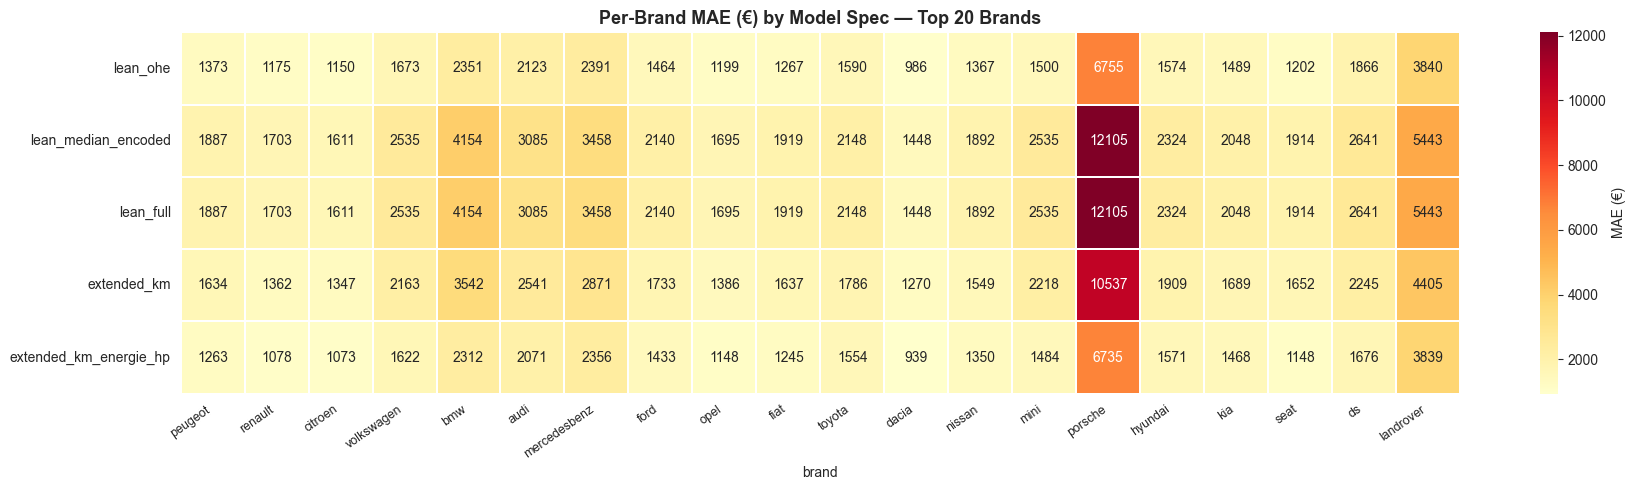

In [15]:
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(brand_heatmap_df, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.3, ax=ax,
            cbar_kws={"label": "MAE (€)"})
ax.set_title("Per-Brand MAE (€) by Model Spec — Top 20 Brands", fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "per_brand_mae_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

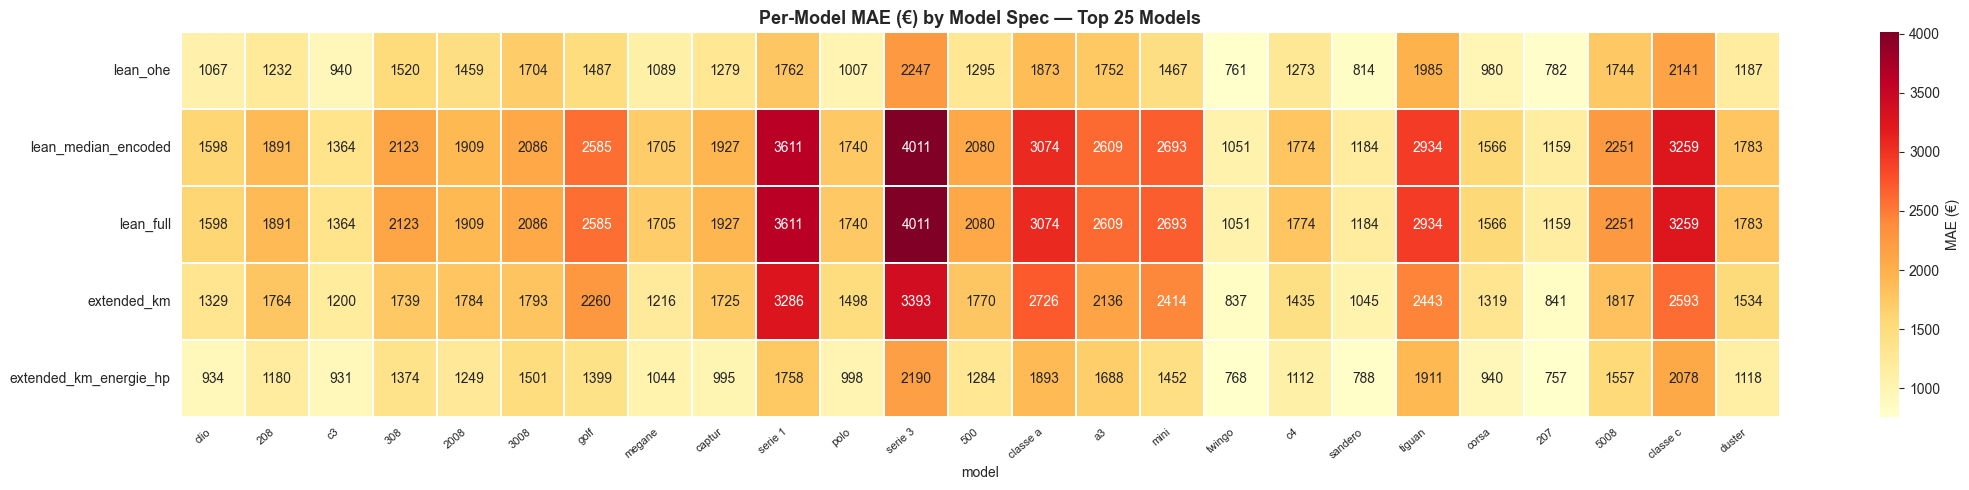

In [16]:
fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(model_heatmap_df, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.3, ax=ax,
            cbar_kws={"label": "MAE (€)"})
ax.set_title("Per-Model MAE (€) by Model Spec — Top 25 Models", fontsize=13, fontweight="bold")
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "per_model_mae_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Log Summary Artifacts to MLflow

In [17]:
summary_csv   = ARTIFACTS_DIR / "comparison_summary.csv"
brand_mae_csv = ARTIFACTS_DIR / "per_brand_mae.csv"
model_mae_csv = ARTIFACTS_DIR / "per_model_mae.csv"

summary_df.to_csv(summary_csv, index=False)
brand_heatmap_df.to_csv(brand_mae_csv)
model_heatmap_df.to_csv(model_mae_csv)

with mlflow.start_run(
    run_name="_summary_artifacts", experiment_id=experiment_id,
    tags={"type": "summary", "git_commit": GIT_COMMIT},
):
    for path in [summary_csv, brand_mae_csv, model_mae_csv]:
        mlflow.log_artifact(str(path))
    for png in ARTIFACTS_DIR.glob("*.png"):
        mlflow.log_artifact(str(png))
    best_spec = summary_df.iloc[0]["spec"]
    best_mae  = summary_df.iloc[0]["MAE_q50_eur"]
    mlflow.log_metrics({"best_mae_eur": best_mae})
    mlflow.set_tag("best_spec", best_spec)

print(f"✓ Summary artifacts logged")
print(f"  Best spec: {best_spec}  |  MAE: €{best_mae:,.0f}")
print(f"\nTo open MLflow UI:")
print(f"  mlflow ui --backend-store-uri file://{MLFLOW_DIR} --port 5001")

✓ Summary artifacts logged
  Best spec: extended_km_energie_hp  |  MAE: €1,659

To open MLflow UI:
  mlflow ui --backend-store-uri file:///Users/brunobrumbrum/car_price_prediction/mlruns --port 5001


## 12. Final Console Summary

In [18]:
print("=" * 72)
print("  EXPERIMENT SUMMARY — car_valuation_variable_addition_study")
print("=" * 72)
print(f"  {'Rank':<5} {'Spec':<30} {'MAE (€)':>12} {'MAPE%':>8} {'R²':>8} {'#Feats':>7}")
print("  " + "-" * 70)
for i, row in summary_df.iterrows():
    print(f"  {i:<5} {row['spec']:<30} €{row['MAE_q50_eur']:>9,.0f}"
          f"  {row['MAPE_q50_pct']:>7.2f}%"
          f"  {row['R2_q50']:>7.4f}"
          f"  {row['n_features']:>7.0f}")
print("=" * 72)
print(f"\n  Best spec: {best_spec}  (MAE = €{best_mae:,.0f})")
print(f"\n  Launch MLflow UI:")
print(f"    mlflow ui --backend-store-uri file://{MLFLOW_DIR} --port 5001")
print(f"    → http://localhost:5001")

  EXPERIMENT SUMMARY — car_valuation_variable_addition_study
  Rank  Spec                                MAE (€)    MAPE%       R²  #Feats
  ----------------------------------------------------------------------
  1     extended_km_energie_hp         €    1,659    13.04%   0.9647       61
  2     lean_ohe                       €    1,721    13.48%   0.9632     1061
  3     extended_km                    €    2,153    15.79%   0.9412       49
  4     lean_median_encoded            €    2,561    19.52%   0.9247       31
  5     lean_full                      €    2,561    19.52%   0.9247       31

  Best spec: extended_km_energie_hp  (MAE = €1,659)

  Launch MLflow UI:
    mlflow ui --backend-store-uri file:///Users/brunobrumbrum/car_price_prediction/mlruns --port 5001
    → http://localhost:5001
